# 前置作業

載入套件

In [1]:
import pandas as pd
import numpy as np
np.set_printoptions(suppress=True, precision=4)
pd.set_option('display.float_format', '{:.4f}'.format)

from urllib.request import urlopen, urlretrieve
import PIL
import matplotlib.pyplot as plt

In [2]:
# %%capture
# import warnings
# warnings.filterwarnings('ignore')
# !pip install git+https://github.com/Hsins/mpl-tc-fonts.git
import mpl_tc_fonts

下載資料

In [3]:
# 新台幣100元圖片
from urllib.request import urlopen, Request
import io
url = "https://i.imgur.com/wA37JSM.png"
req = Request(url, headers={'User-Agent': 'Mozilla/5.0'})
img_data = urlopen(req).read()
pil_img = PIL.Image.open(io.BytesIO(img_data)).convert('RGB')
pil_img.save('100Yuan.png')  # 存檔,供後面 cv2.imread('100Yuan.png') 讀取
img = np.array(pil_img)
# img = np.array(PIL.Image.open(urlopen(url)))
imgheight, imgwidth = img.shape[0], img.shape[1]

部門名稱

In [4]:
fc08 = pd.read_excel('https://ws.dgbas.gov.tw/001/Upload/463/relfile/11077/234145/f110c08.xlsx')
row_code = [str(int(ele)) if isinstance(ele, float) else ele for ele in fc08.iloc[3:-1, 0].values]
row_code = [str(r) for r in row_code]
row_sector = fc08.iloc[3:-1, 1].values
rowdict = {str(code):sector for code, sector in zip(row_code, row_sector)}

col_code = [str(int(ele)) if isinstance(ele, float) else ele for ele in fc08.iloc[1, 2:].values]
col_code = [str(c) for c in col_code]
col_sector = fc08.iloc[2, 2:].values
coldict = {str(code):sector for code, sector in zip(col_code, col_sector)}

檢視資料

In [5]:
# 部門數
dim = 163

In [6]:
# 購買者價格交易表(進口品按C.I.F.計值164x164)
fc08 = pd.read_excel('https://ws.dgbas.gov.tw/001/Upload/463/relfile/11077/234145/f110c08.xlsx')
fc08 = pd.DataFrame(fc08.iloc[3:-1, 2:].to_numpy('float'), index=row_code, columns=col_code)
# 生產者價格交易表(進口品按C.I.F.計值164x164)
fc27 = pd.read_excel('https://ws.dgbas.gov.tw/001/Upload/463/relfile/11077/234145/f110c27.xlsx')
fc27 = pd.DataFrame(fc27.iloc[3:-1, 2:].to_numpy('float'), index=row_code, columns=col_code[:170]+['001-C5=S1-S3', 'S1', 'S2', 'S3'])
# 進口品交易表(C.I.F.+進口稅淨額164x164)
fc28 = pd.read_excel('https://ws.dgbas.gov.tw/001/Upload/463/relfile/11077/234145/f110c28.xlsx')
fc28 = pd.DataFrame(fc28.iloc[3:-1, 2:].to_numpy('float'), index=row_code[:dim], columns=col_code[:170]+['001-C5=S2-S3', 'S2', 'S3'])
# 國產品交易表(164x164)
fc09 = pd.read_excel('https://ws.dgbas.gov.tw/001/Upload/463/relfile/11077/234145/f110c09.xlsx')
fc09 = pd.DataFrame(fc09.iloc[3:-1, 2:].to_numpy('float'), index=row_code[:dim], columns=col_code[:170]+['S1'])
# 國內運費表(164x164)
fc14 = pd.read_excel('https://ws.dgbas.gov.tw/001/Upload/463/relfile/11077/234145/f110c14.xlsx')
fc14 = pd.DataFrame(fc14.iloc[3:-1, 2:].to_numpy('float'), index=row_code[:dim], columns=col_code[:170]+['S5'])
# 商業加價表(164x164)
fc15 = pd.read_excel('https://ws.dgbas.gov.tw/001/Upload/463/relfile/11077/234145/f110c15.xlsx')
fc15 = pd.DataFrame(fc15.iloc[3:-1, 2:].to_numpy('float'), index=row_code[:dim], columns=col_code[:170]+['S4'])

# 產業關聯相關矩陣

In [7]:
def get_iomatrix(domestic_fc, import_fc, produce_fc,
                 xcol=['S1'], fincol=['C1~C5'],
                 primary_sectors=['P1', 'P2', 'P3', 'P4', 'P5'], dim=dim):
    '''
    fc: 計算投入矩陣的表 (fc27: 生產者價格表  fc08:購買者價格表  fc09: 國產品表)
    xcol: 計算產出向量的欄名稱
    '''
    x = domestic_fc[xcol][:dim].sum(axis=1).values
    Z = domestic_fc.iloc[:dim, :dim].values
    y_C = domestic_fc[fincol][:dim].values
    v_C = x - Z.sum(0)

    A = Z @ np.linalg.inv(np.diag(x))
    L = np.linalg.inv(np.eye(dim) - A)

    import_vetor = import_fc.loc[:, :str(dim)].sum(axis=0).values
    V_P_C_value = produce_fc.loc[primary_sectors, :str(dim)].values
    V_m_P_C_value = np.concatenate((V_P_C_value, import_vetor.reshape(1, -1)))

    V_m_P_C = (V_m_P_C_value @ np.linalg.inv(np.diag(x)))

    return x, Z, y_C, v_C, V_m_P_C, A, L

In [8]:
x, Z, y_C, v_C, V_m_P_C, A, L = get_iomatrix(fc09, fc28, fc27)

# 食品消費向量

In [9]:
# 食品相關部門
food_code = ['001', '002', '003', '004', '005', '006', '007', '008', '009',
             '010', '011', '014', '015', '016', '017', '018', '019', '020',
             '021', '023', '024', '025', '026', '027', '028', '029', '129']

def get_foodexp(domestic_fc, import_fc, trans_fc, trade_fc,
                row_code=row_code, food_code=food_code,
                pcecol='C1', dim=dim, restaurantcode='129'):

    # 合併各表民間消費
    iopce = pd.concat([domestic_fc[[pcecol]], import_fc[[pcecol]],
                       trans_fc[[pcecol]], trade_fc[[pcecol]]], axis=1)
    iopce.columns = ['國產品pce', '進口品(含進口稅)pce',
                     '國內運費pce', '商業加價pce']

    # 篩選出食品消費
    mask = [s not in food_code for s in row_code[:dim]]
    iofoodexp = iopce[:dim].copy()
    iofoodexp.loc[mask] = 0
    iofoodexp.columns = ['國產品食品消費', '進口品(含進口稅)食品消費',
                         '國內運費食品消費', '商業加價食品消費']

    # 計算國產比重
    domestic_share = iofoodexp['國產品食品消費'] / (iofoodexp['國產品食品消費'] + iofoodexp['進口品(含進口稅)食品消費'])
    domestic_share = domestic_share.fillna(0)
    domestic_share[restaurantcode] = 1 # 國外餐廳不會有國內運費及本國商業加價

    # 用國產比重離析出用於國產品的國內運費
    foodexp_trans = (iofoodexp['國內運費食品消費']*domestic_share).sum()
    trans_margin = iopce[iopce['國內運費pce'] < 0]['國內運費pce'].sum()
    trans_margin = iopce[iopce['國內運費pce'] < 0]['國內運費pce'] / trans_margin * foodexp_trans

    # 用國產比重離析出用於國產品的商業加價
    foodexp_trade = (iofoodexp['商業加價食品消費']*domestic_share).sum()
    trade_margin = iopce[iopce['商業加價pce'] < 0]['商業加價pce'].sum()
    trade_margin = iopce[iopce['商業加價pce'] < 0]['商業加價pce'] / trade_margin * foodexp_trade

    # 食品消費向量
    margin = pd.concat([trans_margin, trade_margin])
    iofoodexp.loc[margin.index, '國產品食品消費'] = margin

    return iofoodexp['國產品食品消費'], trans_margin.sum(), trade_margin.sum()

In [10]:
foodexp, trans_margin, trade_margin = get_foodexp(domestic_fc=fc09, import_fc=fc28, trans_fc=fc14, trade_fc=fc15)

# 食品消費金額鏈

## 市場支出鏈

$\mathbf{x}^{fd}_A = \mathbf{L}_{A, C} \cdot \mathbf{y}^{fd}_C$

$\mathbf{x}^{net}_A = \mathbf{x}^{fd}_A - (\mathbf{A}_{A, A} + \widehat{\mathbf{A}}_{A, A}) \cdot \mathbf{x}^{fd}_A= \mathbf{x}^{fd}_A - \mathbf{AA}_{A, A} \cdot \mathbf{x}^{fd}_A$

$\mathbf{i}_A^T \cdot \left[ \mathbf{x}^{net}_A - \widehat{\mathbf{S}}_{M_A} \cdot \mathbf{y}_A^{fd} \right] \div \mathbf{i}_C^T \cdot \left[ \left( \widehat{\mathbf{i}}_C - \widehat{\mathbf{S}}_{M_C}\right)  \cdot \mathbf{y}_C^{fd} \right]$

In [11]:
agri_code = ['001', '002', '003', '004', '005', '006',
             '007', '008', '009', '010', '011']
def marketing_bill_series(A=A, foodexp=foodexp,
                          rowdict=rowdict, agri_code=agri_code, dim=dim):
    # 農業部門
    agri_sector = [rowdict[code] for code in agri_code]
    agri_int = [int(code) - 1 for code in agri_code]
    agri_dim = len(agri_code)

    non_agri_code = [code for code in row_code[:dim] if code not in agri_code]
    non_agri_sector = [rowdict[code] for code in non_agri_code]
    non_agri_int = [int(code) - 1 for code in non_agri_code]
    non_agri_dim = len(non_agri_code)

    # 農場銷售總額
    y_fd_C = foodexp.values
    L_AC = L[:agri_dim, :]
    x_fd_A = L_AC @ y_fd_C

    # 農場銷售毛額
    A_AA, A_AN = A[:agri_dim, :agri_dim], A[:agri_dim, agri_dim:]
    A_NA, A_NN = A[agri_dim:, :agri_dim], A[agri_dim:, agri_dim:]
    AA_AA = A_AA + (A_AN @ np.linalg.inv(np.eye(A_NN.shape[0]) - A_NN)) @ A_NA
    x_net_A = x_fd_A - AA_AA @ x_fd_A

    # 農場份額(防呆:無直接消費的品項分母為 0)
    total_fd = y_fd_C.sum()
    farm_share = round(x_net_A.sum() / total_fd, 4) if total_fd != 0 else 0.0
    marketing_share = 1 - farm_share

    return x_net_A.sum(), float(farm_share)

In [12]:
x_net_A, farm_share = marketing_bill_series(A=A, foodexp=foodexp)
farm_share

0.2116

### 個別品項

In [13]:
results = {}

def _stage_shares(x_net_A, trans, trade, foodexp_sum):
    # 四階段累計成本:農場 → +運輸 → 加工(消費−加價) → 批發零售(消費)
    stages = np.array([x_net_A, x_net_A + trans, foodexp_sum - trade, foodexp_sum])
    # 強制非遞減,避免農場價值佔比高的生鮮品項出現階梯反向上升
    stages = np.maximum.accumulate(stages)
    if stages[-1] == 0:                 # 無直接消費的品項,避免除以 0
        return np.zeros(4)
    return x_net_A / stages * 100

# 個別品項
for io in food_code:
    foodexp, trans, trade = get_foodexp(domestic_fc=fc09, import_fc=fc28,
                                        trans_fc=fc14, trade_fc=fc15,
                                        food_code=[io])
    x_net_A, farm_share = marketing_bill_series(A=A, foodexp=foodexp)
    results[io] = _stage_shares(x_net_A, trans, trade, foodexp.sum())

# 整體
foodexp, trans, trade = get_foodexp(domestic_fc=fc09, import_fc=fc28,
                                    trans_fc=fc14, trade_fc=fc15,
                                    food_code=food_code)
x_net_A, farm_share = marketing_bill_series(A=A, foodexp=foodexp)
results['agri'] = _stage_shares(x_net_A, trans, trade, foodexp.sum())

df = pd.DataFrame(results, index=['農場階段', '運輸階段', '加工階段', '批發零售階段'])
# df.iloc[:, -5:]

In [14]:
df.T.to_csv('2021marketing.csv', encoding='big5')

## 產業群組鏈

$\mathbf{x}_{SC}^{fd} = \mathbf{L}_{SC, SC} \cdot \mathbf{y}^{fd}_{SC} + \mathbf{L}_{SC, NC} \cdot \mathbf{y}^{fd}_{NC}$

In [15]:
ig_dict = {
    'agribusiness': ['009'],
    'farm_production': ['001', '002', '003', '004', '005',
                        '006', '007', '008', '010', '011'],
    'food_processing': ['014', '015', '016', '017', '018', '019',
                        '020', '021', '022', '023', '024', '025',
                        '026', '027', '028', '029'],
    'packaging': ['045', '061'],
    'transportation': ['121', '122', '123', '124', '125', '126', '127'],
    'wholesale': ['119'],
    'retail': ['120'],
    'food_service': ['129'],
    'energy': ['047', '107', '108'],
    'finance_and_insurance': ['136', '137', '138'],
    'advertising': ['145'],
    'legal_accounting': ['142']
}

In [16]:
def indusrtry_group_series(L=L, foodexp=foodexp, industry_group=ig_dict,
                           rowdict=rowdict, dim=dim):
    # 農業供應鏈相關部門
    agri_related_code = []
    for s in industry_group.values():
        agri_related_code += s

    agri_related_sector = [rowdict[code] for code in agri_related_code]
    agri_related_int = [int(code) - 1 for code in agri_related_code]
    agri_related_dim = len(agri_related_code)

    non_agri_related_code = [code for code in row_code[:dim] if code not in agri_related_code]
    non_agri_related_sector = [rowdict[code] for code in non_agri_related_code]
    non_agri_related_int = [int(code) - 1 for code in non_agri_related_code]
    non_agri_related_dim = len(non_agri_related_code)

    # 農業供應鏈
    L_SC_SC = L[agri_related_int, :][:, agri_related_int]
    L_SC_NC = L[agri_related_int, :][:, non_agri_related_int]
    L_NC_SC = L[non_agri_related_int, :][:, agri_related_int]
    L_NC_NC = L[non_agri_related_int, :][:, non_agri_related_int]

    # 食品消費向量
    y_fd_SC = foodexp[agri_related_code].values
    y_fd_NC = foodexp[non_agri_related_code].values

    # 食品產值(農業供應鏈)
    x_fd_SC = L_SC_SC @ y_fd_SC + L_SC_NC @ y_fd_NC

    return x_fd_SC

In [17]:
x_fd_SC = indusrtry_group_series()

## 原始投入鏈

$\mathbf{V_m}^{*}_{SC, P} = \mathbf{V_m}_{SC, P} + \left[ \mathbf{L}_{SC, SC}^{T} \right]^{-1} \cdot \mathbf{L}^{T}_{NC, SC} \cdot \mathbf{V_m}_{NC, P}$

In [18]:
def primary_factor_series(V_m_P_C=V_m_P_C, x_fd_SC=x_fd_SC, industry_group=ig_dict,
                          rowdict=rowdict, dim=dim):
    # 農業供應鏈相關部門
    agri_related_code = []
    for s in industry_group.values():
        agri_related_code += s

    agri_related_sector = [rowdict[code] for code in agri_related_code]
    agri_related_int = [int(code) - 1 for code in agri_related_code]
    agri_related_dim = len(agri_related_code)

    non_agri_related_code = [code for code in row_code[:dim] if code not in agri_related_code]
    non_agri_related_sector = [rowdict[code] for code in non_agri_related_code]
    non_agri_related_int = [int(code) - 1 for code in non_agri_related_code]
    non_agri_related_dim = len(non_agri_related_code)

    # 農業供應鏈
    L_SC_SC = L[agri_related_int, :][:, agri_related_int]
    L_SC_NC = L[agri_related_int, :][:, non_agri_related_int]
    L_NC_SC = L[non_agri_related_int, :][:, agri_related_int]
    L_NC_NC = L[non_agri_related_int, :][:, non_agri_related_int]

    # 原始投入(SC與NC)
    V_m_SC_P = V_m_P_C[:, agri_related_int].T
    V_m_NC_P = V_m_P_C[:, non_agri_related_int].T

    # 原始投入(io by P)
    V_m_star_SC_P = V_m_SC_P + np.linalg.inv(L_SC_SC.T) @ L_NC_SC.T @ V_m_NC_P

    # 原始投入(SC by P)
    total_va_SC = np.diag(x_fd_SC) @ V_m_star_SC_P

    return total_va_SC

In [19]:
agri_supply_setor, agri_related_code = [], []
for key, value in ig_dict.items():
    for v in value:
        agri_supply_setor.append(key)
        agri_related_code.append(v)

In [20]:
total_va_SC = primary_factor_series()
total_va_df = pd.DataFrame({'sector': agri_supply_setor,
                            'P1': total_va_SC[:, 0], 'P2': total_va_SC[:, 1],
                            'P3': total_va_SC[:, 2], 'P4': total_va_SC[:, 3],
                            'P5': total_va_SC[:, 4], 'im': total_va_SC[:, 5]})
df = total_va_df.groupby('sector').sum().loc[ig_dict.keys()]
df = df / df.sum().sum() * 100
df.loc['primary_total',:] = df.sum(axis=0)
df['supply_total'] = df.sum(axis=1)
df

,P1,P2,P3,P4,P5,im,supply_total
sector,,,,,,,
agribusiness,0.9167,0.6817,0.4599,-0.0952,0.0000,0.0685,2.0316
farm_production,4.3058,7.5280,0.6449,-0.9868,0.0000,1.4915,12.9834
food_processing,4.6915,2.3261,0.8815,3.7441,0.0000,7.2282,18.8714
packaging,0.7494,0.5044,0.1100,0.0059,0.0000,1.0609,2.4307
transportation,1.3959,0.3983,0.3592,-0.0308,0.0000,0.2991,2.4216
wholesale,8.5795,7.3681,1.1619,0.2711,0.0000,0.8434,18.2240
retail,10.3289,4.6241,1.0831,0.2379,0.0000,1.0555,17.3295
food_service,12.7417,2.6173,1.4271,-0.3315,0.0000,2.0643,18.5189
energy,0.2763,0.0111,0.4844,0.2144,0.0258,2.7704,3.7824


### 個別品項

In [21]:
scva = {}

# 個別品項
for io in food_code:
    foodexp, trans, trade = get_foodexp(domestic_fc=fc09, import_fc=fc28,
                                        trans_fc=fc14, trade_fc=fc15,
                                        food_code=[io])
    x_fd_SC = indusrtry_group_series(foodexp=foodexp)
    total_va_SC = primary_factor_series(x_fd_SC=x_fd_SC)
    total_va_df = pd.DataFrame({'sector': agri_supply_setor,
                                'P1': total_va_SC[:, 0], 'P2': total_va_SC[:, 1],
                                'P3': total_va_SC[:, 2], 'P4': total_va_SC[:, 3],
                                'P5': total_va_SC[:, 4], 'im': total_va_SC[:, 5]})
    df = total_va_df.groupby('sector').sum().loc[ig_dict.keys()]
    denom = df.sum().sum()              # 防呆:無直接消費品項分母為 0
    df = df / denom * 100 if denom != 0 else df * 0
    df.loc['PrimaryTotal',:] = df.sum(axis=0)
    df['SupplyTotal'] = df.sum(axis=1)
    scva[io] = df


# 整體
foodexp, trans, trade = get_foodexp(domestic_fc=fc09, import_fc=fc28,
                                    trans_fc=fc14, trade_fc=fc15)
x_fd_SC = indusrtry_group_series(foodexp=foodexp)
total_va_SC = primary_factor_series(x_fd_SC=x_fd_SC)
total_va_df = pd.DataFrame({'sector': agri_supply_setor,
                            'P1': total_va_SC[:, 0], 'P2': total_va_SC[:, 1],
                            'P3': total_va_SC[:, 2], 'P4': total_va_SC[:, 3],
                            'P5': total_va_SC[:, 4], 'im': total_va_SC[:, 5]})
df = total_va_df.groupby('sector').sum().loc[ig_dict.keys()]
denom = df.sum().sum()
df = df / denom * 100 if denom != 0 else df * 0
df.loc['PrimaryTotal',:] = df.sum(axis=0)
df['SupplyTotal'] = df.sum(axis=1)
scva['agri'] = df

In [23]:
df = pd.DataFrame({io: pd.concat([scva[io]['SupplyTotal'], scva[io].loc['PrimaryTotal']]) for io in scva.keys()})
df

,001,002,003,004,005,006,007,008,009,010,...,021,023,024,025,026,027,028,029,129,agri
agribusiness,0.0000,16.8462,9.8924,4.1098,2.7932,2.2986,0.0000,6.2710,0.0000,0.0146,...,0.1769,0.5141,0.5286,0.0904,0.7063,0.2750,0.0998,0.0045,1.0095,2.0316
farm_production,0.0000,53.5760,66.3521,44.2316,43.9866,31.1524,0.0000,16.6292,0.0000,86.5637,...,0.4508,2.0640,3.5360,0.5078,3.2788,0.5010,0.7447,0.0250,5.3951,12.9834
food_processing,0.0000,0.2117,0.7041,0.2287,0.2797,0.2028,0.0000,19.2696,0.0000,0.1962,...,62.0551,37.0845,31.7935,32.3877,28.4887,53.5064,32.0299,59.7337,10.1240,18.8714
packaging,0.0000,0.5619,0.3976,0.8290,1.1522,1.0201,0.0000,1.0060,0.0000,0.2007,...,2.6437,3.9024,1.5513,2.9064,2.6755,1.7861,7.8410,1.0189,3.2569,2.4307
transportation,0.0000,1.3038,1.6891,2.4128,2.0919,1.9367,0.0000,2.3749,0.0000,4.8081,...,2.4230,2.1962,4.6858,4.1220,2.7185,1.4184,2.9900,0.7935,2.7812,2.4216
wholesale,0.0000,11.0150,8.3114,20.3778,21.0550,27.0557,0.0000,24.9412,0.0000,0.8637,...,13.1874,23.9984,22.9357,24.5451,26.4279,18.0156,23.3853,16.2681,7.0623,18.2240
retail,0.0000,11.7782,8.7956,22.5110,23.2186,29.8795,0.0000,22.6435,0.0000,0.5970,...,10.5985,21.6168,25.5961,25.5424,27.0408,18.2247,22.5298,17.9918,3.5720,17.3295
food_service,0.0000,0.1973,0.2982,0.3109,0.3210,0.3996,0.0000,0.3714,0.0000,0.7174,...,0.2408,0.4461,0.3812,0.4231,0.4468,0.2873,0.4203,0.2473,59.4692,18.5189
energy,0.0000,3.0526,2.2820,2.6483,2.7696,3.1242,0.0000,3.6362,0.0000,5.3598,...,4.0806,3.7306,5.9759,4.8199,3.7451,3.1471,4.9145,1.6715,4.0238,3.7824
finance_and_insurance,0.0000,0.9731,0.8775,1.4796,1.4410,1.8309,0.0000,1.8116,0.0000,0.4789,...,2.1568,2.0347,1.7793,2.1269,2.3112,1.3408,2.5150,1.0720,2.0518,1.9694


In [24]:
df.T.to_csv('2021scva.csv', encoding='big5')

# 繪圖

## 階梯圖

In [25]:
farm_value_share = df['002']
farm_value_share.iloc[3]

0.561901319057009

In [26]:
def stageplot(io3, data=df, food_code=food_code, rowdict=rowdict):
    if ((io3 in food_code) or (io3=='agri')) and (df[io3].sum()!=0):
        fig, ax = plt.subplots()
        stages = ['農場', '運輸', '加工', '批發零售']
        farm_value_share = df[io3]
        ax.plot(stages, farm_value_share, color='black', linewidth=0.8)
        ax.tick_params(axis='both', labelsize=14)
        ax.set_xlim(0, 3)
        ax.set_ylim(0, 100)
        try:
            ax.set_title(rowdict[io3], fontsize=16)
            ax.fill_between(stages, farm_value_share, hatch="//", color="lightblue", alpha=.5)
        except:
            ax.set_title('整體農食', fontsize=16)
            ax.fill_between(stages, farm_value_share, hatch="//", color="lightcoral", alpha=.5)
        fv = farm_value_share.iloc[3].round(1)
        ax.text(x=3+0.03, y=fv, s=str(fv)+'%', fontsize=12)
        print(farm_value_share)
        plt.show()
    else:
        return 'io3碼有誤或無資料'

農場階段     100.0000
運輸階段      96.0889
加工階段      31.3190
批發零售階段    21.1623
Name: agri, dtype: float64


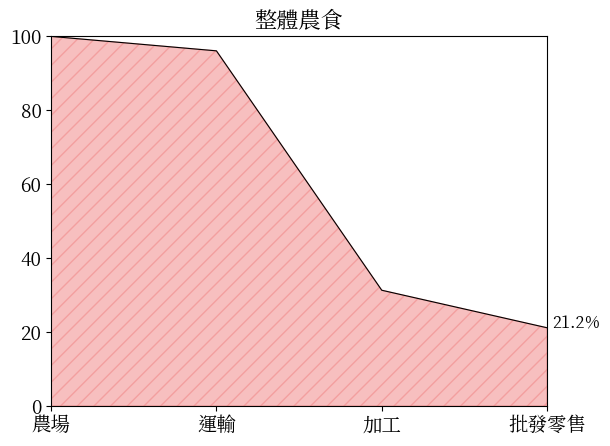

In [27]:
df = pd.read_csv('2021marketing.csv', encoding='big5', index_col=0).T
stageplot('agri', data=df)

## 鈔票圖

In [28]:
import plotly.express as px

### 市場支出鏈

In [29]:
import cv2
# from google.colab.patches import cv2_imshow

# 本機環境替代 Colab 的 cv2_imshow:cv2 影像為 BGR,需轉 RGB 再用 matplotlib 顯示
def cv2_imshow(img):
    plt.figure(figsize=(img.shape[1] / 100, img.shape[0] / 100))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

In [30]:
df['agri'].iloc[-1]

21.162311794152384

In [31]:
df = pd.read_csv('2021marketing.csv', encoding='big5', index_col=0).T
dfio = pd.DataFrame({'Gate': ['農場份額', '市場份額'],
                     'Share': [df['agri'].iloc[-1], 100-df['agri'].iloc[-1]]})
dfio['year'] = 24.2

In [32]:
fig = px.bar(dfio, x="Share", y='year', color="Gate",
             color_discrete_map={'農場份額': 'green', '市場份額': 'dodgerblue'},
             orientation='h', opacity=0.3)
fig.update_traces(width = 48.2, hovertemplate='%{x:.2f}')
fig.update_xaxes(visible=False, range=[0.5, 99.8])
fig.update_yaxes(visible=False, range=[0.5, 48.2])
fig.add_layout_image({"x": 0.5, "y": 0.5, "xref": "paper", "yref": "paper",
                      "layer": "below", "sizex": 1, "sizey": 1, # "sizing": "fill",
                      "source": url, "opacity": 1, "xanchor": "center", "yanchor": "middle"})
fig.update_layout(showlegend=False, width=imgwidth, height=imgheight,
                  margin={"l": 0, "r": 0, "t": 0, "b": 0})
fig.show()

### 產業群組鏈

In [33]:
inds =  ['Agribus', 'FarmProduction', 'FoodProcess', 'Packaging',
         'Transportation', 'Wholesale', 'Retail', 'FoodService',
         'Energy', 'Finance', 'Advertising', 'Accounting']
cols = ['#008000', '#00b359', '#006400', '#2E8B57',
        '#556B2F', '#483D8B', '#191970', '#00008B',
        '#0000CD', '#1E90FF', '#008FFF', '#87CEEB']

df = pd.read_csv('2021scva.csv', encoding='big5', index_col=0).T
dfio = pd.DataFrame({'Gate': inds,
                     'Share': df['agri'][:12].values})
dfio['year'] = 24.2

In [34]:
fig = px.bar(dfio, x="Share", y='year', color="Gate",
             color_discrete_map={i:c for i, c in zip(inds, cols)},
             orientation='h', opacity=0.3)
fig.update_traces(width = 48.2, hovertemplate='%{x:.2f}')
fig.update_xaxes(visible=False, range=[0.5, 99.8])
fig.update_yaxes(visible=False, range=[0.5, 48.2])
fig.add_layout_image({"x": 0.5, "y": 0.5, "xref": "paper", "yref": "paper",
                      "layer": "below", "sizex": 1, "sizey": 1, # "sizing": "fill",
                      "source": url, "opacity": 1, "xanchor": "center", "yanchor": "middle"})
fig.update_layout(showlegend=False, width=imgwidth, height=imgheight,
                  margin={"l": 0, "r": 0, "t": 0, "b": 0})
fig.show()

In [35]:
dfio

,Gate,Share,year
0,Agribus,2.0316,24.2000
1,FarmProduction,12.9834,24.2000
2,FoodProcess,18.8714,24.2000
3,Packaging,2.4307,24.2000
4,Transportation,2.4216,24.2000
5,Wholesale,18.2240,24.2000
6,Retail,17.3295,24.2000
7,FoodService,18.5189,24.2000
8,Energy,3.7824,24.2000
9,Finance,1.9694,24.2000


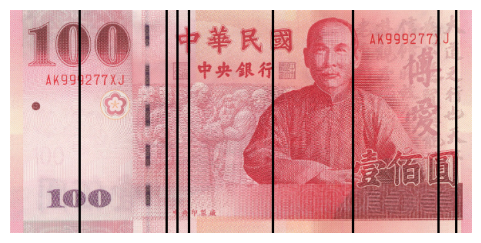

In [36]:
img = cv2.imread('100Yuan.png')
# 加入分割線
f = dfio.Share.cumsum()[[1,2,3,4,5,6,7,8]]
f = [int(600*i/100) for i in f]
for i in f:
  cv2.line(img, (i, 0), (i, 600), (0, 0, 0), 2)
cv2.imwrite('IndustryGroup_Value-added.png', img)
cv2_imshow(img)

### 原始投入鏈

In [37]:
prim =  ['Compensation', 'Operating', 'FixedCapital',
         'NetTaxes', 'Adjustment', 'Import']
cols = ['#00b359', '#006400', '#556B2F',
        '#191970', '#0000CD', '#008FFF']
df = pd.read_csv('2021scva.csv', encoding='big5', index_col=0).T
dfio = pd.DataFrame({'Gate': prim,
                     'Share': df['agri'][-7:-1].values})
dfio['year'] = 24.2

In [38]:
fig = px.bar(dfio, x="Share", y='year', color="Gate",
             color_discrete_map={p:c for p, c in zip(prim, cols)},
             orientation='h', opacity=0.3)
fig.update_traces(width = 48.2, hovertemplate='%{x:.2f}')
fig.update_xaxes(visible=False, range=[0.5, 99.8])
fig.update_yaxes(visible=False, range=[0.5, 48.2])
fig.add_layout_image({"x": 0.5, "y": 0.5, "xref": "paper", "yref": "paper",
                      "layer": "below", "sizex": 1, "sizey": 1, # "sizing": "fill",
                      "source": url, "opacity": 1, "xanchor": "center", "yanchor": "middle"})
fig.update_layout(showlegend=False, width=imgwidth, height=imgheight,
                  margin={"l": 0, "r": 0, "t": 0, "b": 0})
fig.show()

In [39]:
dfio

,Gate,Share,year
0,Compensation,45.7584,24.2000
1,Operating,26.9908,24.2000
2,FixedCapital,6.9007,24.2000
3,NetTaxes,3.1482,24.2000
4,Adjustment,0.0258,24.2000
5,Import,17.1760,24.2000


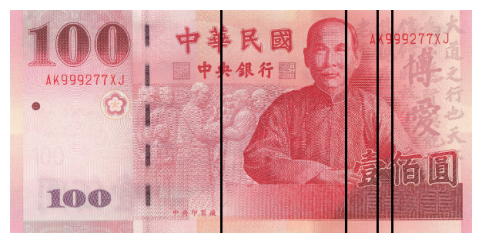

In [40]:
img = cv2.imread('100Yuan.png')
# 加入分割線
f = dfio.Share.cumsum()[[0,1,2,3]]
f = [int(600*i/100) for i in f]
for i in f:
  cv2.line(img, (i, 0), (i, 600), (0, 0, 0), 2)
cv2.imwrite('PrimaryFactor.png', img)
cv2_imshow(img)